In [28]:

# IMPORT LIBRARIES

import numpy as np                    # Mathematical & Array Operations
import pandas as pd                   # Tabular Data & CSV Handling
import matplotlib.pyplot as plt       # Basic Graph Visualization
import seaborn as sns                 # Advanced Statistical Charts

from sklearn.model_selection import train_test_split   # Dataset Splitting
from sklearn.preprocessing import StandardScaler        # Feature Scaling
from sklearn.preprocessing import LabelEncoder          # Categorical Encoding

from sklearn.linear_model import LogisticRegression    # ML Algorithm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # Evaluation

import joblib                          # Model Persistence (Save/Load)

In [29]:
from google.colab import files
Uploaded = files.upload()

Saving Iris.csv to Iris (1).csv


In [30]:
df = pd.read_csv("Iris.csv")

In [31]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [32]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [33]:
df = df.drop('Id', axis=1)

In [34]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [35]:
df.tail()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [36]:
df.shape

(150, 5)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [38]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [39]:
df.dtypes

,0
SepalLengthCm,float64
SepalWidthCm,float64
PetalLengthCm,float64
PetalWidthCm,float64
Species,object


In [40]:
df.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [41]:
df.isnull()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [42]:
df.isnull().sum()

,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [43]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
145,False
146,False
147,False
148,False


In [44]:
df.duplicated().sum()

np.int64(3)

In [47]:
df = df.drop_duplicates()

In [48]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [49]:
df.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
82,5.8,2.7,3.9,1.2,Iris-versicolor
39,5.1,3.4,1.5,0.2,Iris-setosa
26,5.0,3.4,1.6,0.4,Iris-setosa
105,7.6,3.0,6.6,2.1,Iris-virginica
18,5.7,3.8,1.7,0.3,Iris-setosa


In [54]:
X = df.drop('Species' , axis=1)

Y = df['Species']

In [56]:
# One-Hot Encoding for Unordered Categorical Features in X
X = pd.get_dummies(X, drop_first=True, dtype=int)

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42    )

In [58]:
scaler = StandardScaler()

# Train data
X_train = scaler.fit_transform(X_train)

# Test data
X_test = scaler.transform(X_test)

### Manual Hyperparameter Tuning: Testing Different $k$ Values

n_neighbors =  3 | Accuracy: 0.9592
n_neighbors =  5 | Accuracy: 0.9592
n_neighbors =  7 | Accuracy: 0.9592
n_neighbors = 11 | Accuracy: 0.9592
n_neighbors = 13 | Accuracy: 0.9592
n_neighbors = 15 | Accuracy: 0.9388


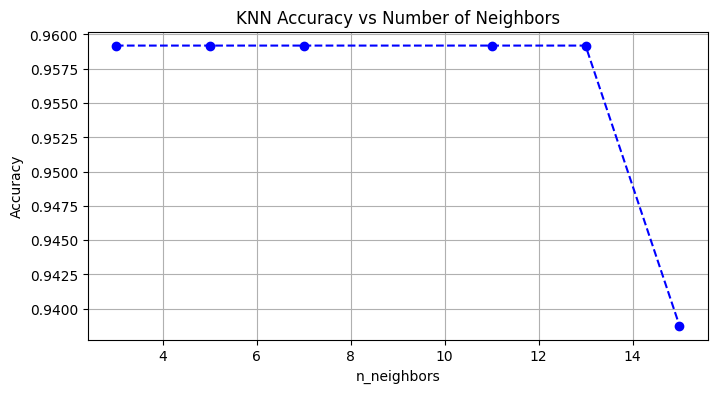

In [67]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

neighbors = [3, 5, 7, 11, 13, 15]
results = {}

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred_k)
    results[k] = acc
    print(f"n_neighbors = {k:2d} | Accuracy: {acc:.4f}")

# Visualize the results
plt.figure(figsize=(8, 4))
plt.plot(list(results.keys()), list(results.values()), marker='o', linestyle='--', color='b')
plt.title('KNN Accuracy vs Number of Neighbors')
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [ ]:
# SVM
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Build & Train (Scaling REQUIRED)
model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, y_pred))

### Manual Hyperparameter Tuning: SVM (C and Kernel)

In [64]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

c_values = [1, 10, 20]
kernels = ['linear', 'rbf']

svm_results = []

for c in c_values:
    for k in kernels:
        # Initialize and train SVM
        svc = SVC(C=c, kernel=k, random_state=42)
        svc.fit(X_train, y_train)

        # Predict and evaluate
        y_pred_svm = svc.predict(X_test)
        acc = accuracy_score(y_test, y_pred_svm)

        svm_results.append({'C': c, 'Kernel': k, 'Accuracy': acc})
        print(f"C = {c:2d} | Kernel = {k:6s} | Accuracy: {acc:.4f}")

# Find and display the best combination
best_config = max(svm_results, key=lambda x: x['Accuracy'])
print(f"\nBest Combination: C={best_config['C']}, Kernel='{best_config['Kernel']}' with Accuracy: {best_config['Accuracy']:.4f}")

C =  1 | Kernel = linear | Accuracy: 0.9592
C =  1 | Kernel = rbf    | Accuracy: 0.9592
C = 10 | Kernel = linear | Accuracy: 0.9592
C = 10 | Kernel = rbf    | Accuracy: 0.9592
C = 20 | Kernel = linear | Accuracy: 0.9388
C = 20 | Kernel = rbf    | Accuracy: 0.9592

Best Combination: C=1, Kernel='linear' with Accuracy: 0.9592


### Q3: Grid Search Cross-Validation (GridSearchCV)
We will now use `GridSearchCV` to perform a more robust evaluation using cross-validation across the hyperparameter grid.

In [65]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'C': [1, 10, 20],
    'kernel': ['linear', 'rbf']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, return_train_score=False)
grid_search.fit(X_train, y_train)

# Create a DataFrame of results
cv_results_df = pd.DataFrame(grid_search.cv_results_)

# Display specific columns
display(cv_results_df[['param_C', 'param_kernel', 'mean_test_score']])

# Print best parameters and score
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

,param_C,param_kernel,mean_test_score
0,1,linear,0.959474
1,1,rbf,0.969474
2,10,linear,0.970000
3,10,rbf,0.960000
4,20,linear,0.970000
5,20,rbf,0.939474



Best Parameters: {'C': 10, 'kernel': 'linear'}
Best Cross-Validation Score: 0.9700


### Q4: Randomized Search Cross-Validation (RandomizedSearchCV)
Unlike `GridSearchCV`, `RandomizedSearchCV` picks a fixed number of parameter settings from the specified distributions.

In [66]:
from sklearn.model_selection import RandomizedSearchCV

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    SVC(random_state=42),
    param_distributions=param_grid,
    n_iter=5,
    cv=5,
    random_state=42
)

random_search.fit(X_train, y_train)

# Create a DataFrame of results
random_results_df = pd.DataFrame(random_search.cv_results_)

# Display specific columns
display(random_results_df[['param_C', 'param_kernel', 'mean_test_score']])

# Comparison with Q3
print(f"\n--- Randomized Search Results ---")
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_:.4f}")

print(f"\n--- Grid Search Results (Recall) ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_:.4f}")

,param_C,param_kernel,mean_test_score
0,1,linear,0.959474
1,1,rbf,0.969474
2,20,rbf,0.939474
3,10,linear,0.970000
4,20,linear,0.970000



--- Randomized Search Results ---
Best Parameters: {'kernel': 'linear', 'C': 10}
Best Score: 0.9700

--- Grid Search Results (Recall) ---
Best Parameters: {'C': 10, 'kernel': 'linear'}
Best Score: 0.9700


## Q5: Bagging – Random Forest
We will now train a Random Forest classifier using a stratified split.

In [68]:
from sklearn.ensemble import RandomForestClassifier

# New split for ensemble methods as requested (test_size=0.2, stratified)
X_train_ens, X_test_ens, y_train_ens, y_test_ens = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=42
)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_ens, y_train_ens)
rf_acc = accuracy_score(y_test_ens, rf_model.predict(X_test_ens))
print(f"Random Forest Accuracy: {rf_acc:.4f}")

Random Forest Accuracy: 0.9667


## Q6 & Q7: Boosting – AdaBoost, Gradient Boosting, and XGBoost

In [69]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost requires integer labels for the target
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_ens)
y_test_enc = le.transform(y_test_ens)

# AdaBoost
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train_ens, y_train_ens)
ada_acc = accuracy_score(y_test_ens, ada_model.predict(X_test_ens))

# Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_ens, y_train_ens)
gb_acc = accuracy_score(y_test_ens, gb_model.predict(X_test_ens))

# XGBoost
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(X_train_ens, y_train_enc)
xgb_acc = accuracy_score(y_test_enc, xgb_model.predict(X_test_ens))

print(f"AdaBoost Accuracy:          {ada_acc:.4f}")
print(f"Gradient Boosting Accuracy: {gb_acc:.4f}")
print(f"XGBoost Accuracy:           {xgb_acc:.4f}")

AdaBoost Accuracy:          0.9333
Gradient Boosting Accuracy: 0.9667
XGBoost Accuracy:           0.9333


## Q8: Hyperparameter Tuning on Random Forest (GridSearchCV)

In [70]:
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5)
grid_rf.fit(X_train_ens, y_train_ens)

print(f"Best RF Parameters: {grid_rf.best_params_}")
print(f"Best RF CV Score:   {grid_rf.best_score_:.4f}")
rf_best_acc = accuracy_score(y_test_ens, grid_rf.predict(X_test_ens))

Best RF Parameters: {'max_depth': 3, 'n_estimators': 50}
Best RF CV Score:   0.9569


## Q9: Complete Model Comparison

In [71]:
# Using the SVM best parameters from Q3/Q4 (C=10, kernel='linear')
# Note: SVM was trained on the scaled 0.33 split previously.
# For fair comparison in a single table, we evaluate all on the 0.2 split.

svm_best = SVC(C=10, kernel='linear', random_state=42)
# SVM needs scaled data
scaler_ens = StandardScaler()
X_train_ens_sc = scaler_ens.fit_transform(X_train_ens)
X_test_ens_sc = scaler_ens.transform(X_test_ens)
svm_best.fit(X_train_ens_sc, y_train_ens)
svm_acc = accuracy_score(y_test_ens, svm_best.predict(X_test_ens_sc))

comparison_data = {
    'Model': ['SVM (Tuned)', 'Random Forest (Tuned)', 'AdaBoost', 'Gradient Boosting', 'XGBoost'],
    'Accuracy': [svm_acc, rf_best_acc, ada_acc, gb_acc, xgb_acc]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.sort_values(by='Accuracy', ascending=False))

best_model_row = comparison_df.iloc[comparison_df['Accuracy'].idxmax()]
print(f"\nThe best performing model is {best_model_row['Model']} with an accuracy of {best_model_row['Accuracy']:.4f}.")

,Model,Accuracy
0,SVM (Tuned),0.966667
1,Random Forest (Tuned),0.966667
3,Gradient Boosting,0.966667
2,AdaBoost,0.933333
4,XGBoost,0.933333



The best performing model is SVM (Tuned) with an accuracy of 0.9667.


### Save and Load Models
We use the `joblib` library to persist our trained models for future use.

In [72]:
import joblib

# Dictionary of models to save
models_to_save = {
    'svm_tuned': svm_best,
    'rf_tuned': grid_rf.best_estimator_,
    'adaboost': ada_model,
    'gradient_boosting': gb_model,
    'xgboost': xgb_model
}

# Save models
for name, model in models_to_save.items():
    filename = f'{name}_model.joblib'
    joblib.dump(model, filename)
    print(f"Saved: {filename}")

# Save the scaler and label encoder as well since they are needed for inference
joblib.dump(scaler_ens, 'scaler.joblib')
joblib.dump(le, 'label_encoder.joblib')
print("Saved preprocessing objects: scaler.joblib, label_encoder.joblib")

Saved: svm_tuned_model.joblib
Saved: rf_tuned_model.joblib
Saved: adaboost_model.joblib
Saved: gradient_boosting_model.joblib
Saved: xgboost_model.joblib
Saved preprocessing objects: scaler.joblib, label_encoder.joblib


#### Example: How to load a model
To use the models later, you can load them as follows:

In [73]:
# Load the Random Forest model back
loaded_rf = joblib.load('rf_tuned_model.joblib')

# Verify it works by checking accuracy again
loaded_acc = accuracy_score(y_test_ens, loaded_rf.predict(X_test_ens))
print(f"Loaded Random Forest Accuracy: {loaded_acc:.4f}")

Loaded Random Forest Accuracy: 0.9667
